# NASA Turbofan Jet Engine - Data Validation & EDA

**Dataset:** C-MAPSS (Commercial Modular Aero-Propulsion System Simulation)  
**Goal:** Predict Remaining Useful Life (RUL) of turbofan jet engines  

| Dataset | Train Engines | Test Engines | Conditions | Fault Modes |
|---------|--------------|-------------|------------|-------------|
| FD001   | 100          | 100         | 1 (Sea Level) | 1 (HPC Degradation) |
| FD002   | 260          | 259         | 6          | 1 (HPC Degradation) |
| FD003   | 100          | 100         | 1 (Sea Level) | 2 (HPC + Fan) |
| FD004   | 248          | 249         | 6          | 2 (HPC + Fan) |

**Columns (26):** unit_id, cycle, op_setting_1-3, sensor_1-21

## 1. Setup & Load Data

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Color palette
COLORS = sns.color_palette('husl', 8)
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [32]:
# Define column names
col_names = ['unit_id', 'cycle'] + \
            [f'op_setting_{i}' for i in range(1, 4)] + \
            [f'sensor_{i}' for i in range(1, 22)]

DATA_DIR = 'CMaps'

# Load all datasets
datasets = {}
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    # Resolve dataset folder robustly (handles different notebook working directories)
    candidate_dirs = [
        DATA_DIR,
        os.path.join('.', DATA_DIR),
        os.path.join('..', DATA_DIR),
        os.getcwd(),
        os.path.join(os.getcwd(), DATA_DIR),
    ]

    loaded = False
    checked_paths = []
    for base_dir in dict.fromkeys(candidate_dirs):  # remove duplicates, keep order
        train_path = os.path.join(base_dir, f'train_{fd}.txt')
        test_path  = os.path.join(base_dir, f'test_{fd}.txt')
        rul_path   = os.path.join(base_dir, f'RUL_{fd}.txt')
        checked_paths.append((train_path, test_path, rul_path))

        if all(os.path.isfile(p) for p in [train_path, test_path, rul_path]):
            datasets[fd] = {
                'train': pd.read_csv(train_path, sep=r'\s+', header=None, names=col_names),
                'test':  pd.read_csv(test_path,  sep=r'\s+', header=None, names=col_names),
                'rul':   pd.read_csv(rul_path,   sep=r'\s+', header=None, names=['RUL'])
            }
            loaded = True
            break

    if not loaded:
        raise FileNotFoundError(
            f"Could not find files for {fd}. Current working directory: {os.getcwd()}\n"
            f"Checked:\n" + "\n".join([f"  - {t}\n    {te}\n    {r}" for t, te, r in checked_paths])
        )

print('All 4 sub-datasets (train, test, RUL for each) have been loaded.')
print(f'Columns: {col_names}')

All 4 sub-datasets (train, test, RUL for each) have been loaded.
Columns: ['unit_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


# Data processing

## **1.**

In [33]:
# ============================================================
# TASK 1.1 — INITIALIZING PIECEWISE RUL LABEL
# ============================================================

# Piecewise RUL threshold
MAX_RUL = 125

target_fds = ['FD001', 'FD002', 'FD003', 'FD004']

for fd in target_fds:

    print(f"\n[{fd}] TASK 1.1: INITIALIZING PIECEWISE RUL LABEL (MAX = {MAX_RUL})")

    train_df = datasets[fd]['train']

    # 1. Find maximum lifetime of each engine
    max_cycle_df = (
        train_df.groupby('unit_id')['cycle']
        .max()
        .reset_index()
    )

    max_cycle_df.columns = ['unit_id', 'max_cycle']

    # 2. Merge back to original dataframe
    train_df = train_df.merge(
        max_cycle_df,
        on='unit_id',
        how='left'
    )

    # 3. Compute linear RUL
    train_df['RUL'] = (
        train_df['max_cycle'] - train_df['cycle']
    )

    # 4. Apply Piecewise RUL clipping
    train_df['RUL'] = train_df['RUL'].clip(
        upper=MAX_RUL
    )

    # 5. Remove temporary column
    train_df.drop(columns=['max_cycle'], inplace=True)

    # Update dataset
    datasets[fd]['train'] = train_df

    # Verification
    print(f"Successfully created RUL label. Train set size: {train_df.shape}")

    print(f"Verifying RUL for unit_id = 1:")

    display_df = pd.concat([
        train_df[train_df['unit_id'] == 1].head(3),
        train_df[train_df['unit_id'] == 1].tail(3)
    ])

    print(
        display_df[
            ['unit_id', 'cycle', 'RUL']
        ].to_string(index=False)
    )

print("\n" + "="*60)
print("Piecewise RUL labeling complete!")


[FD001] TASK 1.1: INITIALIZING PIECEWISE RUL LABEL (MAX = 125)
Successfully created RUL label. Train set size: (20631, 27)
Verifying RUL for unit_id = 1:
 unit_id  cycle  RUL
       1      1  125
       1      2  125
       1      3  125
       1    190    2
       1    191    1
       1    192    0

[FD002] TASK 1.1: INITIALIZING PIECEWISE RUL LABEL (MAX = 125)
Successfully created RUL label. Train set size: (53759, 27)
Verifying RUL for unit_id = 1:
 unit_id  cycle  RUL
       1      1  125
       1      2  125
       1      3  125
       1    147    2
       1    148    1
       1    149    0

[FD003] TASK 1.1: INITIALIZING PIECEWISE RUL LABEL (MAX = 125)
Successfully created RUL label. Train set size: (24720, 27)
Verifying RUL for unit_id = 1:
 unit_id  cycle  RUL
       1      1  125
       1      2  125
       1      3  125
       1    257    2
       1    258    1
       1    259    0

[FD004] TASK 1.1: INITIALIZING PIECEWISE RUL LABEL (MAX = 125)
Successfully created RUL label

In [34]:
# ============================================================
# TASK 1.2 — SENSOR AND FEATURE FILTERING
# ============================================================

from scipy.stats import spearmanr
import numpy as np
import pandas as pd

target_fds = ['FD001', 'FD002', 'FD003', 'FD004']

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
op_cols = [f'op_setting_{i}' for i in range(1, 4)]

# FD002 & FD004 contain multiple operating conditions
MULTI_CONDITION_FDS = ['FD002', 'FD004']

for fd in target_fds:

    print(f"\n{'='*10} [{fd}] TASK 1.2: SENSOR AND FEATURE FILTERING {'='*10}")

    train_df = datasets[fd]['train']
    test_df = datasets[fd]['test']

    cols_to_drop = []

    # ========================================================
    # 1. HANDLE OPERATING SETTINGS
    # ========================================================

    # FD001 & FD003:
    # only one operating condition
    # -> operating settings are not useful

    if fd not in MULTI_CONDITION_FDS:

        cols_to_drop.extend(op_cols)

    # ========================================================
    # 2. REMOVE TRULY CONSTANT FEATURES
    # ========================================================

    feature_cols = [
        col for col in train_df.columns
        if col.startswith('sensor_') or col.startswith('op_setting_')
    ]

    std_vals = train_df[feature_cols].std()

    constant_cols = std_vals[
        np.isclose(std_vals, 0)
    ].index.tolist()

    cols_to_drop.extend(constant_cols)

    # ========================================================
    # 3. ANALYZE LOW-VARIANCE SENSORS USING RUL
    # ========================================================

    near_constant_cols = std_vals[
        (std_vals > 0) & (std_vals < 0.01)
    ].index.tolist()

    kept_near_constant = []

    for col in near_constant_cols:

        engine_corrs = []

        for unit_id, group in train_df.groupby('unit_id'):

            if len(group) < 5:
                continue

            corr, _ = spearmanr(
                group[col],
                group['RUL']
            )

            if not pd.isna(corr):

                engine_corrs.append(abs(corr))

        avg_corr = np.mean(engine_corrs) if engine_corrs else 0

        # Weak degradation relationship
        if avg_corr < 0.2:

            cols_to_drop.append(col)

        else:

            kept_near_constant.append((col, avg_corr))

    # Remove duplicates
    cols_to_drop = list(set(cols_to_drop))

    # ========================================================
    # 4. APPLY DROP
    # ========================================================

    datasets[fd]['train'] = train_df.drop(columns=cols_to_drop)
    datasets[fd]['test'] = test_df.drop(columns=cols_to_drop)

    # ========================================================
    # 5. LOGGING
    # ========================================================

    print(f"\nDropped constant columns:")
    print(constant_cols)

    dropped_near = [
        c for c in cols_to_drop
        if c not in constant_cols and c not in op_cols
    ]

    print(f"\nDropped near-constant noisy sensors:")
    print(dropped_near)

    if kept_near_constant:

        print(f"\nSuccessfully KEPT near-constant sensors (with degradation trend):")

        for col, corr in kept_near_constant:

            print(f"    -> {col} (Avg Spearman corr with RUL: {corr:.4f})")

    print(f"\nFinal train shape: {datasets[fd]['train'].shape}")
    print(f"Final test shape : {datasets[fd]['test'].shape}")

print("\n" + "="*60)
print("Cleaning process complete! Useful sensors have been preserved.")


========== [FD001] TASK 1.2: SENSOR AND FEATURE FILTERING ==========

Dropped constant columns:
['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

Dropped near-constant noisy sensors:
['sensor_6']

Final train shape: (20631, 17)
Final test shape : (13096, 16)

========== [FD002] TASK 1.2: SENSOR AND FEATURE FILTERING ==========

Dropped constant columns:
[]

Dropped near-constant noisy sensors:
['sensor_16']

Final train shape: (53759, 26)
Final test shape : (33991, 25)

========== [FD003] TASK 1.2: SENSOR AND FEATURE FILTERING ==========

Dropped constant columns:
['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_16', 'sensor_18', 'sensor_19']

Dropped near-constant noisy sensors:
[]

Successfully KEPT near-constant sensors (with degradation trend):
    -> sensor_10 (Avg Spearman corr with RUL: 0.7749)

Final train shape: (24720, 19)
Final test shape : (16596, 18)

========== [FD004] TASK 1.2: SENSOR AND FEATURE FILTERING ==========

Dropped 

In [35]:
print(datasets['FD001']['train'].columns.tolist())

['unit_id', 'cycle', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'RUL']


In [36]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

print("STARTING OPERATING CONDITION PROCESSING FOR FD002 & FD004")

# FD002 & FD004:
# multiple operating conditions
complex_fds = ['FD002', 'FD004']

op_cols = ['op_setting_1', 'op_setting_2', 'op_setting_3']

# Common practice in C-MAPSS literature
NUM_REGIMES = 6

for fd in complex_fds:

    print(f"\n{'='*15} CLUSTERING & NORMALIZING {fd} {'='*15}")

    train_df = datasets[fd]['train']
    test_df = datasets[fd]['test']

    # =========================================================
    # 1. GET FILTERED SENSOR COLUMNS
    # =========================================================

    sensor_cols = [
        col for col in train_df.columns
        if col.startswith('sensor_')
    ]

    train_df[sensor_cols] = train_df[sensor_cols].astype(np.float32)
    test_df[sensor_cols] = test_df[sensor_cols].astype(np.float32)
    # =========================================================
    # 2. NORMALIZE OPERATING SETTINGS FOR K-MEANS
    # =========================================================

    print("1. Scaling operating settings...")

    op_scaler = StandardScaler()

    train_op_scaled = op_scaler.fit_transform(
        train_df[op_cols]
    )

    test_op_scaled = op_scaler.transform(
        test_df[op_cols]
    )

    # =========================================================
    # 3. K-MEANS CLUSTERING
    # =========================================================

    print(f"2. Performing K-Means clustering ({NUM_REGIMES} regimes)...")

    kmeans = KMeans(
        n_clusters=NUM_REGIMES,
        random_state=42,
        n_init=10
    )

    train_df['regime'] = kmeans.fit_predict(
        train_op_scaled
    )

    test_df['regime'] = kmeans.predict(
        test_op_scaled
    )

    # =========================================================
    # 4. CONDITION-BASED SENSOR NORMALIZATION
    # =========================================================

    print("3. Performing regime-based sensor normalization...")

    regime_scalers = {}

    for regime in range(NUM_REGIMES):

        train_idx = train_df[
            train_df['regime'] == regime
        ].index

        test_idx = test_df[
            test_df['regime'] == regime
        ].index

        # Skip empty train regime
        if len(train_idx) == 0:
            continue

        scaler = StandardScaler()

        # Fit on train regime only
        train_scaled = scaler.fit_transform(
            train_df.loc[train_idx, sensor_cols]
        )

        train_df.loc[train_idx, sensor_cols] = (
            train_scaled.astype(np.float32)
        )

        # Transform test regime
        if len(test_idx) > 0:

            test_scaled = scaler.transform(
                test_df.loc[test_idx, sensor_cols]
            )

            test_df.loc[test_idx, sensor_cols] = (
                test_scaled.astype(np.float32)
            )

        # Save scaler
        regime_scalers[regime] = scaler
    
    print("3.5 Cleaning sensors that became constant after regime-based scaling...")
    
    # Tính độ lệch chuẩn sau khi đã chuẩn hóa theo từng regime
    std_after = train_df[sensor_cols].std()
    
    # Tìm các cột có std gần bằng 0 hoặc bị NaN (do toàn bộ giá trị giống hệt nhau)
    post_constant_cols = std_after[
        np.isclose(std_after, 0) | std_after.isna()
    ].index.tolist()
    
    if post_constant_cols:
        print(f"    -> Dropping {len(post_constant_cols)} sensors that are constant per regime:")
        print(f"       {post_constant_cols}")
        
        train_df.drop(columns=post_constant_cols, inplace=True)
        test_df.drop(columns=post_constant_cols, inplace=True)
        
        # Cập nhật lại danh sách sensor_cols để tránh lỗi ở các bước sau (nếu cần)
        sensor_cols = [c for c in sensor_cols if c not in post_constant_cols]
    else:
        print("    -> No additional constant sensors detected.")

    # =========================================================
    # 5. SAVE OBJECTS FOR REPRODUCIBILITY
    # =========================================================

    datasets[fd]['kmeans'] = kmeans
    datasets[fd]['op_scaler'] = op_scaler
    datasets[fd]['regime_scalers'] = regime_scalers


    print("\nRegime distribution (train):")

    # =========================================================
    # 6. LOGGING
    # =========================================================

    print(
        train_df['regime'].value_counts()
        if 'regime' in train_df.columns
        else "Regime column removed after normalization."
    )

    # =========================================================
    # 7. CLEAN TEMP COLUMN
    # =========================================================

    # Keep op_settings for future analysis/debugging
    train_df.drop(columns=['regime'], inplace=True)
    test_df.drop(columns=['regime'], inplace=True)

    # =========================================================
    # 8. SAVE BACK
    # =========================================================

    datasets[fd]['train'] = train_df
    datasets[fd]['test'] = test_df


    print("\nNormalization complete.")
    print(f"Train shape: {train_df.shape}")
    print(f"Test shape : {test_df.shape}")

print("\n" + "="*60)
print("Operating condition processing completed successfully.")

STARTING OPERATING CONDITION PROCESSING FOR FD002 & FD004

=============== CLUSTERING & NORMALIZING FD002 ===============
1. Scaling operating settings...
2. Performing K-Means clustering (6 regimes)...
3. Performing regime-based sensor normalization...
3.5 Cleaning sensors that became constant after regime-based scaling...
    -> Dropping 4 sensors that are constant per regime:
       ['sensor_1', 'sensor_5', 'sensor_18', 'sensor_19']

Regime distribution (train):
regime
0    13458
2     8122
4     8096
1     8044
5     8037
3     8002
Name: count, dtype: int64

Normalization complete.
Train shape: (53759, 22)
Test shape : (33991, 21)

=============== CLUSTERING & NORMALIZING FD004 ===============
1. Scaling operating settings...
2. Performing K-Means clustering (6 regimes)...
3. Performing regime-based sensor normalization...
3.5 Cleaning sensors that became constant after regime-based scaling...
    -> Dropping 4 sensors that are constant per regime:
       ['sensor_1', 'sensor_5', 

In [37]:
from sklearn.preprocessing import StandardScaler

simple_fds = ['FD001', 'FD003']

for fd in simple_fds:
    train_df = datasets[fd]['train']
    test_df = datasets[fd]['test']
    
    # Lấy danh sách sensor hiện có (sau khi đã lọc constants ở Task 1.2)
    sensor_cols = [c for c in train_df.columns if c.startswith('sensor_')]
    
    scaler = StandardScaler()
    
    # Fit & Transform cho Train
    train_df[sensor_cols] = scaler.fit_transform(train_df[sensor_cols]).astype(np.float32)
    
    # Chỉ Transform cho Test
    test_df[sensor_cols] = scaler.transform(test_df[sensor_cols]).astype(np.float32)
    
    # Lưu lại scaler nếu cần dùng sau này
    datasets[fd]['scaler'] = scaler

In [38]:
# ============================================================
# FINAL DTYPE UNIFICATION
# ============================================================

for fd in target_fds:

    train_df = datasets[fd]['train']
    test_df = datasets[fd]['test']

    # Convert all sensor columns to float32
    sensor_cols = [
        col for col in train_df.columns
        if col.startswith('sensor_')
    ]

    train_df[sensor_cols] = train_df[sensor_cols].astype(np.float32)
    test_df[sensor_cols] = test_df[sensor_cols].astype(np.float32)

    # Convert operating settings if exist
    op_cols = [
        col for col in train_df.columns
        if col.startswith('op_setting_')
    ]

    if len(op_cols) > 0:

        train_df[op_cols] = train_df[op_cols].astype(np.float32)
        test_df[op_cols] = test_df[op_cols].astype(np.float32)

    # Optional: convert RUL to float32
    train_df['RUL'] = train_df['RUL'].astype(np.float32)

    datasets[fd]['train'] = train_df
    datasets[fd]['test'] = test_df

    print(f"{fd} dtype unification complete.")

FD001 dtype unification complete.
FD002 dtype unification complete.
FD003 dtype unification complete.
FD004 dtype unification complete.


In [39]:
for fd in target_fds:

    print(f"\n{'='*20} {fd} {'='*20}")

    train_df = datasets[fd]['train']
    test_df = datasets[fd]['test']

    print("TRAIN SHAPE:", train_df.shape)
    print("TEST SHAPE :", test_df.shape)

    print("\nTRAIN COLUMNS:")
    print(train_df.columns.tolist())


==================== FD001 ====================
TRAIN SHAPE: (20631, 17)
TEST SHAPE : (13096, 16)

TRAIN COLUMNS:
['unit_id', 'cycle', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'RUL']

==================== FD002 ====================
TRAIN SHAPE: (53759, 22)
TEST SHAPE : (33991, 21)

TRAIN COLUMNS:
['unit_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'RUL']

==================== FD003 ====================
TRAIN SHAPE: (24720, 19)
TEST SHAPE : (16596, 18)

TRAIN COLUMNS:
['unit_id', 'cycle', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sen

In [40]:
for fd in target_fds:

    print(f"\n{'='*20} {fd} DTYPES {'='*20}")

    print(
        datasets[fd]['train'].dtypes
    )


==================== FD001 DTYPES ====================
unit_id        int64
cycle          int64
sensor_2     float32
sensor_3     float32
sensor_4     float32
sensor_7     float32
sensor_8     float32
sensor_9     float32
sensor_11    float32
sensor_12    float32
sensor_13    float32
sensor_14    float32
sensor_15    float32
sensor_17    float32
sensor_20    float32
sensor_21    float32
RUL          float32
dtype: object

==================== FD002 DTYPES ====================
unit_id           int64
cycle             int64
op_setting_1    float32
op_setting_2    float32
op_setting_3    float32
sensor_2        float32
sensor_3        float32
sensor_4        float32
sensor_6        float32
sensor_7        float32
sensor_8        float32
sensor_9        float32
sensor_10       float32
sensor_11       float32
sensor_12       float32
sensor_13       float32
sensor_14       float32
sensor_15       float32
sensor_17       float32
sensor_20       float32
sensor_21       float32
RUL          

In [41]:
for fd in target_fds:

    print(f"\n{'='*20} {fd} SAMPLE {'='*20}")

    display(
        datasets[fd]['train'].head()
    )


==================== FD001 SAMPLE ====================


,unit_id,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,-1.721725,-0.134255,-0.925936,1.121141,-0.516338,-0.862813,-0.266467,0.334262,-1.058890,-0.269071,-0.603816,-0.781710,1.348493,1.194427,125.0
1,1,2,-1.061780,0.211528,-0.643726,0.431930,-0.798093,-0.958818,-0.191583,1.174899,-0.363646,-0.642845,-0.275852,-0.781710,1.016528,1.236922,125.0
2,1,3,-0.661813,-0.413166,-0.525953,1.008155,-0.234584,-0.557139,-1.015303,1.364721,-0.919841,-0.551629,-0.649144,-2.073094,0.739891,0.503423,125.0
3,1,4,-0.661813,-1.261314,-0.784831,1.222827,0.188048,-0.713826,-1.539489,1.961302,-0.224597,-0.520176,-1.971665,-0.781710,0.352598,0.777792,125.0
4,1,5,-0.621816,-1.251528,-0.301518,0.714393,-0.516338,-0.457059,-0.977861,1.052871,-0.780793,-0.521748,-0.339845,-0.136018,0.463253,1.059552,125.0



==================== FD002 SAMPLE ====================


,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,34.998299,0.8400,100.0,-1.090257,-1.443087,0.770026,-0.174959,0.412696,...,-0.201615,0.163635,0.097664,-1.395951,-1.531624,0.361688,-0.167410,-0.890411,-1.352342,125.0
1,1,2,41.998199,0.8408,100.0,0.450818,-0.220660,-0.264833,-1.184723,-0.274173,...,-0.158323,0.214487,-0.380149,-1.213519,-1.040114,0.062511,-0.757094,-1.634765,-1.315594,125.0
2,1,3,24.998800,0.6218,60.0,1.242501,-1.122077,-0.421676,-1.856239,0.634472,...,0.089090,-0.534253,-1.024436,-1.024452,-1.042318,-0.459709,1.277806,-1.631374,1.720472,125.0
3,1,4,42.007702,0.8416,100.0,-0.450254,-0.076862,-0.186268,-1.184723,-0.388012,...,-0.158323,-0.790611,0.500505,-1.367568,-1.260997,-0.593230,-1.466983,0.033183,1.845374,125.0
4,1,5,25.000500,0.6203,60.0,0.572334,-0.942169,-0.351161,0.535633,-0.839714,...,0.089090,0.425104,-0.762646,-1.132706,-1.321480,-0.408790,1.277806,-1.185250,-0.451156,125.0



==================== FD003 SAMPLE ====================


,unit_id,cycle,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,-0.187102,-0.712038,-0.780848,0.781589,-0.341494,-0.704785,-0.097138,-0.353479,-0.385602,-0.227593,-0.389857,0.067687,0.469741,-0.889364,0.488019,-0.263512,125.0
1,1,2,0.080574,-0.497656,-0.775732,0.781589,-0.172755,-0.452071,-0.116658,-0.353479,-0.618882,-0.193802,-0.263369,0.523946,0.729201,-0.321641,0.005819,0.375767,125.0
2,1,3,-0.531256,-0.841254,0.116524,0.781589,-0.207667,-0.262536,0.306267,-0.353479,-0.652208,-0.313608,-0.453101,0.361559,-0.100409,-0.889364,-0.556747,-0.175058,125.0
3,1,4,0.883602,-0.362566,-1.248464,0.781589,0.019257,-0.452071,0.022983,-0.353479,-0.585556,-0.172298,0.052852,0.142821,-0.138419,-0.321641,-0.114730,-0.656192,125.0
4,1,5,-1.487242,0.080881,-0.697966,0.781589,-0.117479,-0.199357,0.602065,-0.353479,-0.885488,-0.144650,-0.263369,0.217955,-0.153292,-0.321641,0.608569,0.437416,125.0



==================== FD004 SAMPLE ====================


,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,42.004902,0.8400,100.0,0.435225,-1.384548,-1.281820,-0.750216,-1.514072,...,-1.788076,-1.207049,-1.092783,-0.386213,-0.945383,0.022478,-0.327378,-0.024003,-0.079916,125.0
1,1,2,20.002001,0.7002,100.0,-2.472355,-0.887979,-1.357161,-1.271968,-1.467673,...,-1.406449,-1.415971,-1.475774,-1.907447,-1.373466,0.012070,-2.277438,-0.940947,-0.634486,125.0
2,1,3,42.003799,0.8409,100.0,-1.136895,-1.431554,-0.825014,-1.684466,-0.722440,...,-1.788076,-1.311302,-1.260196,-0.463835,-1.434210,0.953644,-0.929371,-1.204068,0.681692,125.0
3,1,4,42.000000,0.8400,100.0,-1.675307,-1.716570,-0.716358,-0.750216,-0.915520,...,-0.359937,-1.241795,-1.071852,-0.269781,-0.872760,0.069589,-1.531364,-0.698324,0.629799,125.0
4,1,5,25.006300,0.6207,60.0,-1.654888,-0.935533,-1.763240,-1.500344,-0.908433,...,-5.356956,-0.861313,-0.800768,-1.032075,-1.035099,-0.383184,-1.272039,-2.185915,1.153857,125.0


# Giai đoạn 2: 

Làm mượt tín hiệu (EMA - Exponential Moving Average): Tín hiệu cảm biến thực tế luôn bị rung lắc (nhiễu tần số cao). Làm mượt sẽ giúp mô hình nhìn thấy rõ "đường cong suy thoái" của động cơ hơn.

In [42]:
import pandas as pd
import numpy as np

# Cấu hình tham số làm mượt
EMA_SPAN = 10
target_fds = ['FD001', 'FD002', 'FD003', 'FD004']

print(f"STARTING SIGNAL SMOOTHING WITH EMA (SPAN={EMA_SPAN})")

for fd in target_fds:
    print(f"\n{'='*10} [{fd}] PROCESSING EMA {'='*10}")
    
    # 1. Lấy dữ liệu đã qua xử lý ở Giai đoạn 1
    train_df = datasets[fd]['train']
    test_df = datasets[fd]['test']
    
    # 2. Xác định các cột sensor còn lại sau bước Filtering
    sensor_cols = [col for col in train_df.columns if col.startswith('sensor_')]
    
    # 3. Áp dụng EMA (Tối ưu hóa: xử lý tất cả sensor_cols cùng lúc)
    # Chúng ta group theo unit_id để đảm bảo tín hiệu không bị tràn giữa các động cơ khác nhau
    train_df[sensor_cols] = train_df.groupby('unit_id')[sensor_cols].transform(
        lambda x: x.ewm(span=EMA_SPAN, adjust=False).mean()
    )
    
    test_df[sensor_cols] = test_df.groupby('unit_id')[sensor_cols].transform(
        lambda x: x.ewm(span=EMA_SPAN, adjust=False).mean()
    )

    # 4. Lưu lại vào datasets
    datasets[fd]['train'] = train_df
    datasets[fd]['test'] = test_df
    
    # 5. In kết quả kiểm tra cho Động cơ số 1 (5 chu kỳ đầu tiên)
    print(f"EMA Smoothing complete for {fd}. Number of sensors smoothed: {len(sensor_cols)}")
    print(f"Top 5 rows of smoothed sensors for unit_id=1:")
    
    # Hiển thị unit_id, cycle và 3 sensor đầu tiên để kiểm chứng
    display_cols = ['unit_id', 'cycle'] + sensor_cols[:3]
    print(train_df[train_df['unit_id'] == 1][display_cols].head(5).to_string(index=False))

print("\n" + "="*60)
print("ALL DATASETS SMOOTHED SUCCESSFULLY!")

STARTING SIGNAL SMOOTHING WITH EMA (SPAN=10)

========== [FD001] PROCESSING EMA ==========
EMA Smoothing complete for FD001. Number of sensors smoothed: 14
Top 5 rows of smoothed sensors for unit_id=1:
 unit_id  cycle  sensor_2  sensor_3  sensor_4
       1      1 -1.721725 -0.134255 -0.925936
       1      2 -1.601735 -0.071385 -0.874625
       1      3 -1.430840 -0.133527 -0.811230
       1      4 -1.291017 -0.338579 -0.806430
       1      5 -1.169344 -0.504570 -0.714628

========== [FD002] PROCESSING EMA ==========
EMA Smoothing complete for FD002. Number of sensors smoothed: 16
Top 5 rows of smoothed sensors for unit_id=1:
 unit_id  cycle  sensor_2  sensor_3  sensor_4
       1      1 -1.090257 -1.443087  0.770026
       1      2 -0.810061 -1.220828  0.581870
       1      3 -0.436868 -1.202873  0.399407
       1      4 -0.439302 -0.998144  0.292921
       1      5 -0.255368 -0.987966  0.175815

========== [FD003] PROCESSING EMA ==========
EMA Smoothing complete for FD003. Number of

In [43]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# Dictionary để lưu lại scalers dùng cho bước Demo sau này
lstm_scalers = {}

print("STEP: MIN-MAX SCALING FOR LSTM")

for fd in target_fds:
    train_df = datasets[fd]['train']
    test_df = datasets[fd]['test']
    
    # Chỉ scale các cột sensor và op_settings (loại bỏ unit_id, cycle, RUL)
    exclude_cols = ['unit_id', 'cycle', 'RUL']
    feature_cols = [col for col in train_df.columns if col not in exclude_cols]
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    
    # Fit trên Train và transform cả hai
    train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
    test_df[feature_cols] = scaler.transform(test_df[feature_cols])
    
    # Lưu lại scaler
    lstm_scalers[fd] = scaler
    datasets[fd]['feature_cols'] = feature_cols # Lưu danh sách cột feature để dùng cho bước sau
    
    print(f"[{fd}] Scaling complete. Number of features: {len(feature_cols)}")

print("Scaling finished successfully!")

STEP: MIN-MAX SCALING FOR LSTM
[FD001] Scaling complete. Number of features: 14
[FD002] Scaling complete. Number of features: 19
[FD003] Scaling complete. Number of features: 16
[FD004] Scaling complete. Number of features: 19
Scaling finished successfully!


In [44]:
import numpy as np

SEQUENCE_LENGTH = 30

def gen_sequence(id_df, seq_length, seq_cols):
    data_matrix = id_df[seq_cols].values
    num_elements = data_matrix.shape[0]
    for start, stop in zip(range(0, num_elements - seq_length + 1), range(seq_length, num_elements + 1)):
        yield data_matrix[start:stop, :]

def gen_labels(id_df, seq_length, label_view):
    data_matrix = id_df[label_view].values
    num_elements = data_matrix.shape[0]
    return data_matrix[seq_length-1:num_elements, :]

# Dictionary lưu dữ liệu 3D
lstm_data = {}

for fd in target_fds:
    print(f"Processing {fd}...")
    
    # --- XỬ LÝ TẬP TRAIN (Lấy tất cả sequences) ---
    train_df = datasets[fd]['train']
    feature_cols = datasets[fd]['feature_cols']
    
    X_train = np.concatenate(list(
        (list(gen_sequence(train_df[train_df['unit_id']==id], SEQUENCE_LENGTH, feature_cols)) 
         for id in train_df['unit_id'].unique())
    )).astype(np.float32)
    
    y_train = np.concatenate([
        gen_labels(train_df[train_df['unit_id']==id], SEQUENCE_LENGTH, ['RUL']) 
        for id in train_df['unit_id'].unique()
    ]).astype(np.float32)

    # --- XỬ LÝ TẬP TEST (Chỉ lấy cửa sổ CUỐI CÙNG và khớp với file RUL thực tế) ---
    test_df = datasets[fd]['test']
    
    # Đọc file nhãn thực tế (Ground Truth)
    rul_truth = pd.read_csv(f'RUL_{fd}.txt', header=None).values.flatten()
    
    X_test_last = []
    y_test_last = []
    
    # Duyệt qua từng Unit ID trong tập Test (thứ tự unit_id trong data thường khớp với RUL_FD.txt)
    unit_ids = test_df['unit_id'].unique()
    
    for i, unit_id in enumerate(unit_ids):
        unit_data = test_df[test_df['unit_id'] == unit_id]
        
        if len(unit_data) >= SEQUENCE_LENGTH:
            # Lấy 30 dòng cuối cùng của sensor
            last_window = unit_data[feature_cols].values[-SEQUENCE_LENGTH:, :]
            X_test_last.append(last_window)
            
            # Lấy giá trị RUL thực tế tương ứng từ file RUL_FDxxx.txt
            y_test_last.append(rul_truth[i])
        else:
            # Nếu unit quá ngắn, ta dùng padding (lấy toàn bộ data và đệm 0 phía trước)
            padding_len = SEQUENCE_LENGTH - len(unit_data)
            last_window = unit_data[feature_cols].values
            padded_window = np.pad(last_window, ((padding_len, 0), (0, 0)), mode='edge')
            X_test_last.append(padded_window)
            y_test_last.append(rul_truth[i])
            
    X_test_last = np.array(X_test_last).astype(np.float32)
    y_test_last = np.array(y_test_last).astype(np.float32).reshape(-1, 1)

    lstm_data[fd] = {
        'X_train': X_train,
        'y_train': y_train,
        'X_test': X_test_last,
        'y_test': y_test_last
    }
    
    print(f"  -> Train: X={X_train.shape}, y={y_train.shape}")
    print(f"  -> Test (Last Window): X={X_test_last.shape}, y={y_test_last.shape}")

print("\nDATA READY FOR LSTM TRAINING!")

Processing FD001...


  -> Train: X=(17731, 30, 14), y=(17731, 1)
  -> Test (Last Window): X=(100, 30, 14), y=(100, 1)
Processing FD002...
  -> Train: X=(46219, 30, 19), y=(46219, 1)
  -> Test (Last Window): X=(259, 30, 19), y=(259, 1)
Processing FD003...
  -> Train: X=(21820, 30, 16), y=(21820, 1)
  -> Test (Last Window): X=(100, 30, 16), y=(100, 1)
Processing FD004...
  -> Train: X=(54028, 30, 19), y=(54028, 1)
  -> Test (Last Window): X=(248, 30, 19), y=(248, 1)

DATA READY FOR LSTM TRAINING!


In [45]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time

# Dictionary lưu trữ kết quả và model
lstm_results = {}
lstm_models = {}

print(f"STARTING LSTM TRAINING PIPELINE AT {time.strftime('%H:%M:%S')}")

for fd in target_fds:
    print(f"\n{'-'*20} Training {fd} {'-'*20}")
    
    X_train = lstm_data[fd]['X_train']
    y_train = lstm_data[fd]['y_train']
    X_test = lstm_data[fd]['X_test']
    y_test = lstm_data[fd]['y_test']
    
    input_shape = (X_train.shape[1], X_train.shape[2]) # (30, num_features)
    
    # 1. Định nghĩa kiến trúc Model
    model = Sequential([
        LSTM(units=100, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(units=50, return_sequences=False),
        Dropout(0.2),
        Dense(units=25, activation='relu'),
        Dense(units=1) # Dự báo RUL
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    # 2. Thiết lập Callbacks (Tránh Overfit và tối ưu Learning Rate)
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
    ]
    
    # 3. Training
    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        epochs=100, # Sẽ dừng sớm nhờ EarlyStopping
        batch_size=64,
        validation_split=0.2,
        callbacks=callbacks,
        verbose=1
    )
    training_time = time.time() - start_time
    
    # 4. Dự báo và Đánh giá trên tập Test
    y_pred = model.predict(X_test)
    
    # Tính toán RMSE
    mse = tf.keras.losses.MeanSquaredError()
    rmse_test = np.sqrt(mse(y_test, y_pred).numpy())
    
    # Lưu kết quả
    lstm_results[fd] = {
        'RMSE': rmse_test,
        'Time': training_time,
        'History': history.history
    }
    lstm_models[fd] = model
    
    print(f"Done {fd}! Test RMSE: {rmse_test:.4f} | Time: {training_time:.2f}s")

print("\n" + "="*50)
print("ALL LSTM MODELS TRAINED SUCCESSFULLY!")

STARTING LSTM TRAINING PIPELINE AT 20:36:57

-------------------- Training FD001 --------------------
Epoch 1/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - loss: 4890.3848 - mae: 59.3686 - val_loss: 2436.7109 - val_mae: 43.5838 - learning_rate: 0.0010
Epoch 2/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - loss: 1883.6238 - mae: 38.5668 - val_loss: 1792.5370 - val_mae: 37.9736 - learning_rate: 0.0010
Epoch 3/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - loss: 1774.2898 - mae: 37.2467 - val_loss: 1790.1243 - val_mae: 37.8989 - learning_rate: 0.0010
Epoch 4/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - loss: 1775.7056 - mae: 37.2657 - val_loss: 1790.8966 - val_mae: 37.9251 - learning_rate: 0.0010
Epoch 5/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 1770.3190 - mae: 37.2037 - val_loss: 1792.9280 - val_mae: 37.9839 - learning_rate: 0.0010
Epoch 6/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 1766.7644 - mae: 37.1803 - val_loss: 1791.0464 - val_mae: 37.9302 - lear

In [46]:
print(f"{'Dataset':<10} | {'LSTM RMSE':<12}")
print("-" * 25)
for fd, res in lstm_results.items():
    print(f"{fd:<10} | {res['RMSE']:<12.4f}")

Dataset    | LSTM RMSE   
-------------------------
FD001      | 14.5281     
FD002      | 25.7524     
FD003      | 15.6239     
FD004      | 25.8329     


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


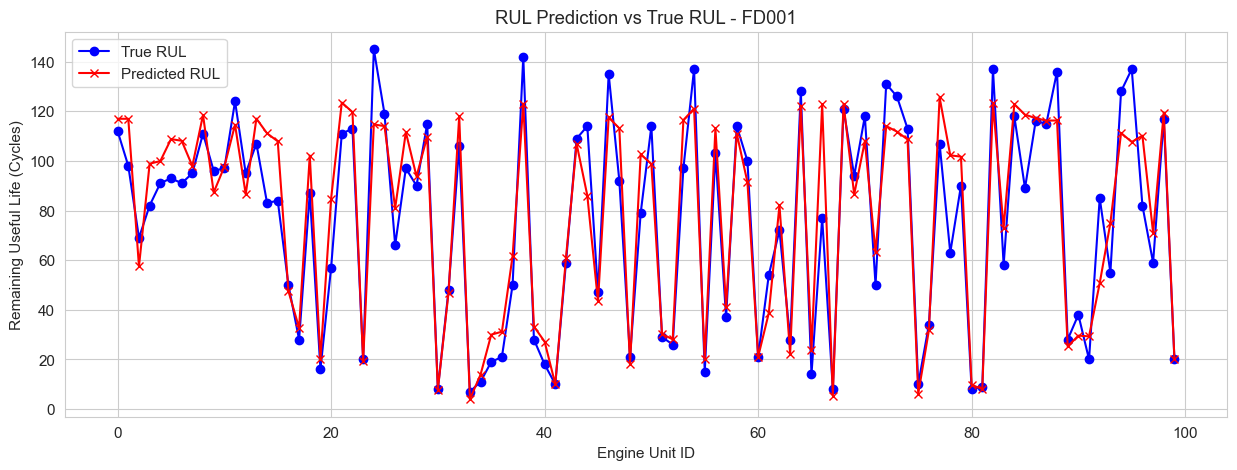

In [48]:
import matplotlib.pyplot as plt

def plot_result(fd_name):
    y_true = lstm_data[fd_name]['y_test'].flatten()
    y_pred = lstm_models[fd_name].predict(lstm_data[fd_name]['X_test']).flatten()
    
    plt.figure(figsize=(15, 5))
    plt.plot(y_true, label='True RUL', color='blue', marker='o')
    plt.plot(y_pred, label='Predicted RUL', color='red', marker='x')
    plt.title(f'RUL Prediction vs True RUL - {fd_name}')
    plt.xlabel('Engine Unit ID')
    plt.ylabel('Remaining Useful Life (Cycles)')
    plt.legend()
    plt.show()

# Vẽ thử cho FD002
plot_result('FD001')

In [49]:
import os

# Tạo thư mục lưu trữ nếu chưa có
if not os.path.exists('models_lstm'):
    os.makedirs('models_lstm')

print("Đang xuất các model LSTM...")

for fd in target_fds:
    # Đường dẫn lưu file: ví dụ models_lstm/model_lstm_FD001.keras
    model_path = os.path.join('models_lstm', f'model_lstm_{fd}.keras')
    
    # Lưu model
    lstm_models[fd].save(model_path)
    
    print(f"-> Đã lưu: {model_path}")

print("\nHOÀN THÀNH! Tất cả model đã nằm trong thư mục 'models_lstm'.")

Đang xuất các model LSTM...
-> Đã lưu: models_lstm\model_lstm_FD001.keras
-> Đã lưu: models_lstm\model_lstm_FD002.keras
-> Đã lưu: models_lstm\model_lstm_FD003.keras
-> Đã lưu: models_lstm\model_lstm_FD004.keras

HOÀN THÀNH! Tất cả model đã nằm trong thư mục 'models_lstm'.


In [50]:
import tensorflow as tf
import joblib
import numpy as np

# 1. LOAD CÁC LINH KIỆN ĐÃ XUẤT
fd_to_test = 'FD001'
model = tf.keras.models.load_model(f'models_lstm/model_lstm_{fd_to_test}.keras')
scaler = lstm_scalers[fd_to_test] # Hoặc load từ file .pkl nếu bạn đã lưu
feature_cols = datasets[fd_to_test]['feature_cols']

# 2. LẤY DỮ LIỆU ĐẦU VÀO (Giả sử lấy từ tập Test thô chưa xử lý)
# Chúng ta cần 30 dòng cuối cùng của động cơ số 1
unit_1_data = datasets[fd_to_test]['test'][datasets[fd_to_test]['test']['unit_id'] == 1]
last_30_cycles = unit_1_data.iloc[-30:] 

# 3. TIỀN XỬ LÝ (Phải giống hệt lúc Train)
# a. Scale dữ liệu
input_data = last_30_cycles[feature_cols].values
input_scaled = scaler.transform(input_data)

# b. EMA (Làm mượt) - Thực hiện trên 30 dòng này
# Lưu ý: Trong thực tế bạn có thể cần chuỗi dài hơn 30 để EMA ổn định, 
# nhưng ở đây ta demo nhanh trên chính cửa sổ này.
input_series = pd.DataFrame(input_scaled)
input_smooth = input_series.ewm(span=10, adjust=False).mean().values

# c. Reshape về dạng 3D (1, 30, num_features)
input_3d = np.reshape(input_smooth, (1, 30, len(feature_cols)))

# 4. THỰC HIỆN DỰ BÁO
prediction = model.predict(input_3d, verbose=0)
predicted_rul = prediction[0][0]

# 5. SO SÁNH VỚI THỰC TẾ
true_rul = lstm_data[fd_to_test]['y_test'][0][0] # Lấy nhãn thực tế đã chuẩn bị

print(f"--- KẾT QUẢ DỰ BÁO CHO {fd_to_test} (UNIT ID: 1) ---")
print(f"Giá trị RUL dự báo: {predicted_rul:.2f} chu kỳ")
print(f"Giá trị RUL thực tế: {true_rul:.2f} chu kỳ")
print(f"Sai số (Error): {abs(predicted_rul - true_rul):.2f} chu kỳ")

--- KẾT QUẢ DỰ BÁO CHO FD001 (UNIT ID: 1) ---
Giá trị RUL dự báo: 117.42 chu kỳ
Giá trị RUL thực tế: 112.00 chu kỳ
Sai số (Error): 5.42 chu kỳ
